# TSP Baseline: Visit All Supercells

Solves the **Traveling Salesman Problem** variant: visit **all** N=6 supercells and
return to base, minimising total flight distance. Used as a baseline and to calibrate
the orienteering budget.

Total distance = Σ transit costs + Σ internal survey costs  
(Survey costs are fixed for all orderings — only transit order varies.)

## Algorithms compared

| Algorithm | Optimality | Complexity |
|-----------|-----------|-----------|
| Nearest Neighbor | Heuristic | O(N²) |
| 2-opt local search | **2-optimal** local | O(N²) per pass |
| Held-Karp DP | **Global optimum** | O(2^N · N²) |
| MILP (MTZ + HiGHS) | **Global optimum** | Exponential (practical for N ≤ 20) |

Run `00_simulation_data.ipynb` first.


In [1]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import time, itertools
from dataclasses import dataclass, field
from typing import List, Optional
from math import cos, sin, sqrt, pi, radians, degrees
from scipy.optimize import milp as sp_milp, LinearConstraint, Bounds
from scipy.sparse import csr_matrix

np.set_printoptions(precision=3, suppress=True)

# ── Geometry utilities ────────────────────────────────────────────────────
def uvec(a): return np.array([cos(a), sin(a)])
def rot2d(a):
    c,s=cos(a),sin(a); return np.array([[c,-s],[s,c]])
def cross2d(v,w): return float(v[0]*w[1]-v[1]*w[0])
def ensure_ccw(verts):
    pts=[np.asarray(v,float) for v in verts]
    area2=sum(pts[i][0]*pts[(i+1)%len(pts)][1]-pts[(i+1)%len(pts)][0]*pts[i][1]
              for i in range(len(pts)))
    return pts if area2>0 else pts[::-1]
def segments_intersect(p1,p2,p3,p4):
    EPS=1e-9; d1,d2=p2-p1,p4-p3; denom=cross2d(d1,d2)
    if abs(denom)<EPS: return False
    diff=p3-p1; t=cross2d(diff,d2)/denom; u=cross2d(diff,d1)/denom
    return EPS<t<1-EPS and EPS<u<1-EPS
def point_in_poly(pt,verts):
    EPS=1e-9
    for i in range(len(verts)):
        if cross2d(verts[(i+1)%len(verts)]-verts[i],pt-verts[i])<=EPS: return False
    return True
def seg_blocked(p1,p2,verts):
    for i in range(len(verts)):
        if segments_intersect(p1,p2,verts[i],verts[(i+1)%len(verts)]): return True
    return point_in_poly(0.5*(p1+p2),verts)
def path_len(w): return sum(np.linalg.norm(w[i+1]-w[i]) for i in range(len(w)-1))
def obs_free(start,end,verts):
    s,e=np.asarray(start,float),np.asarray(end,float)
    verts=[np.asarray(v,float) for v in verts]
    ok=lambda a,b: not seg_blocked(a,b,verts)
    if ok(s,e): return [s,e]
    n=len(verts); best,bd=None,float('inf')
    for v in verts:
        if ok(s,v) and ok(v,e):
            d=np.linalg.norm(v-s)+np.linalg.norm(e-v)
            if d<bd: bd,best=d,[s,v,e]
    for si in range(n):
        for ln in range(1,n):
            for arc in [[verts[(si+k)%n] for k in range(ln+1)],
                        [verts[(si-k)%n] for k in range(ln+1)]]:
                c=[s]+arc+[e]
                if all(ok(c[k],c[k+1]) for k in range(len(c)-1)):
                    d=path_len(c)
                    if d<bd: bd,best=d,c
    return best or [s,e]
def multi_obs(start,end,obstacles):
    if not obstacles: return [np.asarray(start,float),np.asarray(end,float)]
    cur=[np.asarray(start,float),np.asarray(end,float)]
    for obs in obstacles:
        obs=[np.asarray(v,float) for v in obs]; nw=[cur[0]]
        for i in range(len(cur)-1): nw.extend(obs_free(cur[i],cur[i+1],obs)[1:])
        cur=nw
    return cur
def transit_dist(p, q, obstacles):
    return path_len(multi_obs(p, q, obstacles))
print('Geometry utilities loaded.')


Geometry utilities loaded.


In [2]:
@dataclass
class CircularSupercell:
    center:np.ndarray; radius:float; L_max:float; weight:float; name:str
    sensitivity_points:List[np.ndarray]=field(default_factory=list)
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float)
        self.sensitivity_points=[np.asarray(s,float) for s in self.sensitivity_points]
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def cross_endpoints(self,theta,L):
        u1,u2=uvec(theta),uvec(theta+pi/2)
        return self.center-L*u1,self.center+L*u1,self.center-L*u2,self.center+L*u2
    def cross_blocked(self,theta,L):
        if self.obstacle is None: return False
        P0,P1,P2,P3=self.cross_endpoints(theta,L); c=self.center
        return any(seg_blocked(c,p,self.obstacle) for p in [P0,P1,P2,P3])

@dataclass
class EllipticalSupercell:
    center:np.ndarray; a:float; b:float; phi:float; weight:float; name:str
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float); self._R=rot2d(self.phi)
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def to_world(self,e): return self.center+self._R@np.asarray(e,float)
    def leg_halflen(self,xp,dt):
        if abs(xp)>=self.a: return None
        return self.b*sqrt(max(0.,1.-(xp/self.a)**2))+dt
    def leg_endpoints(self,xp,dt):
        L=self.leg_halflen(xp,dt)
        if L is None: return None
        return self.to_world(np.array([xp,-L])),self.to_world(np.array([xp,L]))
    def leg_positions(self,n,s): return [-(n-1)*s/2.+i*s for i in range(n)]
    def legs_valid(self,n,s): return all(abs(xp)<self.a for xp in self.leg_positions(n,s))

def compute_coverage(cell,xps,sw,gr=2.,ob=0.5):
    xa=np.arange(-cell.a-gr,cell.a+gr+0.1,gr); ya=np.arange(-cell.b-gr,cell.b+gr+0.1,gr)
    XX,YY=np.meshgrid(xa,ya); ins=(XX/cell.a)**2+(YY/cell.b)**2<=1.
    xp=np.array(xps,float); dx=np.abs(XX[:,:,None]-xp[None,None,:]); cov=(dx<=sw).sum(axis=2)
    ca=gr**2; cv=float((ins&(cov>=1)).sum()*ca); ov=float((ins*np.maximum(0,cov-1)).sum()*ca)
    return cv,ov
print('Dataclasses and coverage loaded.')


Dataclasses and coverage loaded.


In [3]:
def route_circ_from(start, cell, theta, L, all_obs):
    """Optimal ordering: cross arms and sensitivity points in any order/direction.
    Returns (dist, exit_pt)."""
    s = np.asarray(start, float)
    P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
    c = np.asarray(cell.center, float)
    # Each task: list of (entry, [internal_wpts], exit) options
    # Arms reversible; sensitivity points have a single option
    arm1 = [(P0, [c, P1], P1), (P1, [c, P0], P0)]
    arm2 = [(P2, [c, P3], P3), (P3, [c, P2], P2)]
    task_opts = [arm1, arm2] + [[(sp, [], sp)] for sp in cell.sensitivity_points]
    n = len(task_opts)
    best_d, best_pos = float('inf'), s
    for perm in itertools.permutations(range(n)):
        for choices in itertools.product(*[task_opts[i] for i in perm]):
            pos = s.copy(); d = 0.
            for (entry, wpts, exit_pt) in choices:
                entry = np.asarray(entry, float)
                tr = multi_obs(pos, entry, all_obs); d += path_len(tr); pos = entry
                for wp in wpts:
                    wp = np.asarray(wp, float); d += np.linalg.norm(wp - pos); pos = wp
                pos = np.asarray(exit_pt, float)
            if d < best_d: best_d, best_pos = d, pos.copy()
    return best_d, best_pos

def route_ellip_from(start, cell, n, s, dt, rev, etop, all_obs):
    """Boustrophedon scan from start. Returns (dist, exit_pt)."""
    s_=np.asarray(start,float)
    ordered=list(reversed(cell.leg_positions(n,s))) if rev else cell.leg_positions(n,s)
    legs=[]
    for xp in ordered:
        ep=cell.leg_endpoints(xp,dt)
        if ep is None: return float('inf'),s_
        legs.append(ep)
    dist=0.; pos=s_.copy()
    for i,(bot,top) in enumerate(legs):
        gu=(i%2==0)!=etop; ep_,ex=(bot,top) if gu else (top,bot)
        tr=multi_obs(pos,ep_,all_obs); dist+=path_len(tr); pos=tr[-1]
        dist+=np.linalg.norm(ex-pos); pos=ex.copy()
    return dist,pos

def precompute_cell(cell, all_obs, start_pt,
                    theta_grid, L_grid, sw, dt, s_min, n_max, n_s_steps,
                    overlap_bonus=0.5):
    """Enumerate all survey configurations. Returns list of dicts."""
    configs = []
    if isinstance(cell, CircularSupercell):
        for theta in theta_grid:
            for L in L_grid:
                if L > cell.L_max: continue
                if cell.cross_blocked(theta, L): continue
                d, exit_pt = route_circ_from(start_pt, cell, theta, L, all_obs)
                if d < float('inf'):
                    configs.append(dict(score=cell.weight, survey_dist=d, exit_pt=exit_pt,
                                        params=dict(theta=theta, L=L), cell_type='circ'))
    else:
        ellip_ref = pi * cell.a * cell.b
        for n in range(1, n_max+1):
            sl = ([0.] if n == 1
                  else ([] if 2.*cell.a/(n-1)*0.999 < s_min
                        else list(np.linspace(s_min, 2.*cell.a/(n-1)*0.999, n_s_steps))))
            for s in sl:
                if not cell.legs_valid(n, s): continue
                xps = cell.leg_positions(n, s)
                cv, ov = compute_coverage(cell, xps, sw)
                sc = cell.weight * (cv + overlap_bonus * ov) / ellip_ref
                for rev in [False, True]:
                    for etop in [False, True]:
                        d, exit_pt = route_ellip_from(start_pt, cell, n, s, dt, rev, etop, all_obs)
                        if d < float('inf'):
                            configs.append(dict(score=sc, survey_dist=d, exit_pt=exit_pt,
                                                params=dict(n=n, s=float(s), rev=rev, etop=etop),
                                                cell_type='ellip'))
    return configs
print('Survey route helpers loaded.')


Survey route helpers loaded.


In [4]:
# ── Route visualization: correct cross + boustrophedon patterns ──────────
# route_circ_wpts / route_ellip_wpts each return:
#   (dist, transit_wpts, survey_wpts, exit_pt)
# transit_wpts : obstacle-avoiding path from current pos to survey entry point  → drawn DASHED
# survey_wpts  : actual survey path starting at entry point                     → drawn SOLID
# No pre-transit to cell.center; aircraft enters directly at the arm / leg tip.

def route_circ_wpts(start, cell, theta, L, all_obs):
    """Same as route_circ_from but returns waypoints for visualization.
    transit_wpts: start -> first task entry (drawn dashed)
    survey_wpts: from first task entry onward (drawn solid)
    Returns (dist, transit_wpts, survey_wpts, exit_pt)."""
    s = np.asarray(start, float)
    P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
    c = np.asarray(cell.center, float)
    arm1 = [(P0, [c, P1], P1), (P1, [c, P0], P0)]
    arm2 = [(P2, [c, P3], P3), (P3, [c, P2], P2)]
    task_opts = [arm1, arm2] + [[(sp, [], sp)] for sp in cell.sensitivity_points]
    n = len(task_opts)
    best_d, best_pos = float('inf'), s
    best_tr, best_survey = [s], [s]
    for perm in itertools.permutations(range(n)):
        for choices in itertools.product(*[task_opts[i] for i in perm]):
            pos = s.copy(); d = 0.; first_tr = None; surv = []
            for ti, (entry, wpts, exit_pt) in enumerate(choices):
                entry = np.asarray(entry, float)
                seg = [np.asarray(p, float) for p in multi_obs(pos, entry, all_obs)]
                d += path_len(seg)
                if ti == 0:
                    first_tr = seg; surv = [seg[-1]]
                else:
                    surv.extend(seg[1:])
                pos = seg[-1]
                for wp in wpts:
                    wp = np.asarray(wp, float); d += np.linalg.norm(wp - pos)
                    surv.append(wp); pos = wp
                pos = np.asarray(exit_pt, float)
            if d < best_d:
                best_d, best_pos = d, pos.copy()
                best_tr, best_survey = first_tr or [s], surv
    return best_d, best_tr, best_survey, best_pos

def route_ellip_wpts(start, cell, n, s, dt, rev, etop, all_obs):
    """Transit start → first leg entry point (dashed).
    Survey: all boustrophedon scan legs (solid).
    Returns (dist, transit_wpts, survey_wpts, exit_pt)."""
    s_ = np.asarray(start, float)
    ordered = list(reversed(cell.leg_positions(n, s))) if rev else cell.leg_positions(n, s)
    legs = []
    for xp in ordered:
        ep = cell.leg_endpoints(xp, dt)
        if ep is None: return float('inf'), [s_], [s_], s_
        legs.append(ep)
    dist = 0.; pos = s_.copy(); tr_wpts = None; survey_wpts = []
    for i, (bot, top) in enumerate(legs):
        gu = (i % 2 == 0) != etop; ep_, ex = (bot, top) if gu else (top, bot)
        seg = [np.asarray(p,float) for p in multi_obs(pos, ep_, all_obs)]
        dist += path_len(seg)
        if i == 0:
            tr_wpts = seg                       # transit = start → first leg entry
            survey_wpts = [seg[-1].copy()]      # survey starts at first leg entry
        else:
            survey_wpts.extend(seg[1:])         # inter-leg routing (obstacle-aware)
        pos = seg[-1]
        dist += np.linalg.norm(np.asarray(ex,float) - pos)
        survey_wpts.append(np.asarray(ex, float)); pos = np.asarray(ex, float)
    return dist, tr_wpts or [s_], survey_wpts, pos

print('Visualization helpers loaded.')


Visualization helpers loaded.


In [5]:
# ── Load scenario + precompute survey configs ────────────────────────────
import pickle, time
with open('data/scenario_N6_seed42.pkl', 'rb') as f:
    s = pickle.load(f)
BASE=s['BASE']; OBSTACLES=s['OBSTACLES']; ALL_CELLS=s['cells']
labels=s['labels']; N_CELLS=s['N_CELLS']

THETA_GRID = np.radians(np.arange(0, 180, 15))
L_GRID     = np.array([35., 50., 65., 80.])
SW=12.; DT=8.; S_MIN=18.; N_MAX=6; N_S_STEPS=10; OVERLAP_BONUS=0.5

# Best survey config per cell (survey starts/ends at cell centre)
cell_configs = [precompute_cell(cell, OBSTACLES, cell.center,
                                THETA_GRID, L_GRID, SW, DT, S_MIN, N_MAX, N_S_STEPS, OVERLAP_BONUS)
                for cell in ALL_CELLS]
best_cfg_idx = {k: max(range(len(cell_configs[k-1])),
                       key=lambda i: (cell_configs[k-1][i]['score'],
                                      -cell_configs[k-1][i]['survey_dist']))
               for k in range(1, N_CELLS+1)}
sdist_vec = np.array([cell_configs[k-1][best_cfg_idx[k]]['survey_dist']
                       for k in range(1, N_CELLS+1)])
total_survey_cost = float(sdist_vec.sum())
print(f'Total internal survey cost (constant): {total_survey_cost:.1f} km')

# Transit matrix: obstacle-avoiding distances between node centres
nodes = [BASE] + [c.center for c in ALL_CELLS]
N = len(nodes)
T = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            T[i,j] = transit_dist(nodes[i], nodes[j], OBSTACLES)
print()
print('Transit matrix (km):')
hdr = f"{'':>6}" + ''.join(f'{l:>7}' for l in labels)
print(hdr)
for i in range(N):
    print(f'{labels[i]:>6}' + ''.join(f'{T[i,j]:>7.1f}' for j in range(N)))


Total internal survey cost (constant): 2179.6 km

Transit matrix (km):
         BASE     C1     C2     C3     E1     E2     E3
  BASE    0.0  252.1  192.4  437.4  351.7  272.8  472.9
    C1  252.1    0.0  381.1  272.0  311.8  341.8  261.7
    C2  192.4  381.1    0.0  492.6  325.7  175.3  552.3
    C3  437.4  272.0  492.6    0.0  192.4  344.1  110.0
    E1  351.7  311.8  325.7  192.4    0.0  162.2  294.1
    E2  272.8  341.8  175.3  344.1  162.2    0.0  440.4
    E3  472.9  261.7  552.3  110.0  294.1  440.4    0.0


In [6]:
# ── TSP algorithms ────────────────────────────────────────────────────────
nodes_idx = list(range(1, N_CELLS+1))   # cell indices 1..N

def tour_transit(perm):
    """Total transit cost of BASE → perm[0] → ... → perm[-1] → BASE."""
    pts = [0] + list(perm) + [0]
    return sum(T[pts[i], pts[i+1]] for i in range(len(pts)-1))

def total_cost(perm):
    return tour_transit(perm) + total_survey_cost

# ── Nearest Neighbor ──────────────────────────────────────────────────────
def nearest_neighbor():
    remaining = set(nodes_idx); cur = 0; tour = []
    while remaining:
        nxt = min(remaining, key=lambda k: T[cur, k])
        tour.append(nxt); remaining.remove(nxt); cur = nxt
    return tour

t0 = time.time(); nn_tour = nearest_neighbor(); t_nn = time.time()-t0
print(f'Nearest Neighbor: transit={tour_transit(nn_tour):.1f} km  '
      f'total={total_cost(nn_tour):.1f} km  time={t_nn*1000:.2f} ms')

# ── 2-opt ─────────────────────────────────────────────────────────────────
def two_opt(tour):
    best = list(tour)
    improved = True
    while improved:
        improved = False
        for i in range(len(best)-1):
            for j in range(i+2, len(best)):
                new = best[:i] + best[i:j+1][::-1] + best[j+1:]
                if tour_transit(new) < tour_transit(best):
                    best = new; improved = True
    return best

t0 = time.time(); opt2_tour = two_opt(nn_tour); t_2opt = time.time()-t0
print(f'2-opt:            transit={tour_transit(opt2_tour):.1f} km  '
      f'total={total_cost(opt2_tour):.1f} km  time={t_2opt*1000:.2f} ms')

# ── Held-Karp DP ──────────────────────────────────────────────────────────
def held_karp():
    n = N_CELLS; full = (1<<n)-1
    dp   = [[float('inf')]*(n) for _ in range(1<<n)]
    prev = [[-1]*n for _ in range(1<<n)]
    for v in range(n): dp[1<<v][v] = T[0, v+1]
    for mask in range(1, 1<<n):
        for v in range(n):
            if not (mask>>v&1) or dp[mask][v]==float('inf'): continue
            for u in range(n):
                if mask>>u&1: continue
                nm = mask|(1<<u); nc = dp[mask][v]+T[v+1, u+1]
                if nc < dp[nm][u]: dp[nm][u]=nc; prev[nm][u]=v
    last = min(range(n), key=lambda v: dp[full][v]+T[v+1,0])
    cost = dp[full][last]+T[last+1,0]
    tour=[]; mask=full; v=last
    while v!=-1:
        tour.append(v+1); nv=prev[mask][v]; mask^=(1<<v); v=nv
    return list(reversed(tour)), cost

t0 = time.time(); hk_tour, hk_transit = held_karp(); t_hk = time.time()-t0
print(f'Held-Karp DP:     transit={hk_transit:.1f} km  '
      f'total={hk_transit+total_survey_cost:.1f} km  time={t_hk*1000:.2f} ms')

# ── MILP (MTZ formulation via scipy/HiGHS) ────────────────────────────────
def solve_tsp_milp():
    from scipy.optimize import milp as sp_milp, LinearConstraint, Bounds
    from scipy.sparse import csr_matrix
    nn = N_CELLS+1
    arc_ids = [(i,j) for i in range(nn) for j in range(nn) if i!=j]
    n_arcs = len(arc_ids); arc_idx = {ij:k for k,ij in enumerate(arc_ids)}
    col_u = lambda i: n_arcs + (i-1)   # i in 1..N_CELLS
    n_vars = n_arcs + N_CELLS
    # Objective: minimise total transit
    c_vec = np.array([T[i,j] for i,j in arc_ids]+[0.]*N_CELLS)
    lb = np.zeros(n_vars); ub = np.ones(n_vars)
    for i in range(1,nn): lb[col_u(i)]=1.; ub[col_u(i)]=float(N_CELLS)
    integ = np.ones(n_vars,int)
    for i in range(1,nn): integ[col_u(i)]=0
    rows,lbs_c,ubs_c=[],[],[]
    # Depart BASE once
    r=np.zeros(n_vars)
    for j in range(1,nn): r[arc_idx[(0,j)]]=1.
    rows.append(r); lbs_c.append(1.); ubs_c.append(1.)
    # Return BASE once
    r=np.zeros(n_vars)
    for i in range(1,nn): r[arc_idx[(i,0)]]=1.
    rows.append(r); lbs_c.append(1.); ubs_c.append(1.)
    # Flow conservation (visit each cell exactly once)
    for k in range(1,nn):
        for sign in [1,-1]:
            r=np.zeros(n_vars)
            for j in range(nn):
                if j!=k: r[arc_idx[(k,j) if sign==1 else (j,k)]]=1.
            rows.append(r); lbs_c.append(1.); ubs_c.append(1.)
    # MTZ
    for i in range(1,nn):
        for j in range(1,nn):
            if i==j: continue
            r=np.zeros(n_vars)
            r[col_u(i)]=1.; r[col_u(j)]=-1.; r[arc_idx[(i,j)]]=float(N_CELLS)
            rows.append(r); lbs_c.append(-np.inf); ubs_c.append(float(N_CELLS)-1.)
    A=csr_matrix(np.array(rows))
    res=sp_milp(c_vec,constraints=LinearConstraint(A,lbs_c,ubs_c),
                integrality=integ,bounds=Bounds(lb=lb,ub=ub))
    if res.status!=0: return None, float('inf')
    tour=[0]
    while True:
        cur=tour[-1]
        nxt=next((j for j in range(nn) if j!=cur and res.x[arc_idx[(cur,j)]]>0.5), None)
        if nxt is None or nxt==0: break
        tour.append(nxt)
    return [k for k in tour if k!=0], sum(T[tour[i],tour[i+1]] for i in range(len(tour)-1))+T[tour[-1],0]

t0=time.time(); milp_tour,milp_transit=solve_tsp_milp(); t_milp=time.time()-t0
print(f'MILP (HiGHS):     transit={milp_transit:.1f} km  '
      f'total={milp_transit+total_survey_cost:.1f} km  time={t_milp*1000:.2f} ms')
print()
print('='*68)
print(f"{'Algorithm':<20} {'Transit (km)':>13} {'Total (km)':>12} {'Time':>10} {'Optimal':>8}")
print('-'*68)
opt = hk_transit
for name,tour,tr,t in [
    ('Nearest Neighbor', nn_tour,  tour_transit(nn_tour),  t_nn),
    ('2-opt',            opt2_tour,tour_transit(opt2_tour), t_2opt),
    ('Held-Karp DP',     hk_tour,  hk_transit,             t_hk),
    ('MILP (HiGHS)',     milp_tour,milp_transit,            t_milp),
]:
    gap = (tr-opt)/opt*100
    is_opt = abs(tr-opt)<0.5
    tstr='→'.join(labels[k] for k in tour)
    print(f"  {name:<18} {tr:>13.1f} {tr+total_survey_cost:>12.1f} "
          f"{t*1000:>8.1f}ms {'✓' if is_opt else f'+{gap:.0f}%':>8}  [{tstr}]")
print('='*68)
assert abs(milp_transit - hk_transit) < 0.5, 'MILP and Held-Karp disagree!'
print('\nMILP matches Held-Karp ✓')


Nearest Neighbor: transit=1346.0 km  total=3525.6 km  time=0.05 ms
2-opt:            transit=1346.0 km  total=3525.6 km  time=0.08 ms
Held-Karp DP:     transit=1346.0 km  total=3525.6 km  time=0.28 ms
MILP (HiGHS):     transit=1346.0 km  total=3525.6 km  time=10.85 ms

Algorithm             Transit (km)   Total (km)       Time  Optimal
--------------------------------------------------------------------
  Nearest Neighbor          1346.0       3525.6      0.0ms        ✓  [C2→E2→E1→C3→E3→C1]
  2-opt                     1346.0       3525.6      0.1ms        ✓  [C2→E2→E1→C3→E3→C1]
  Held-Karp DP              1346.0       3525.6      0.3ms        ✓  [C2→E2→E1→C3→E3→C1]
  MILP (HiGHS)              1346.0       3525.6     10.9ms        ✓  [C1→E3→C3→E1→E2→C2]

MILP matches Held-Karp ✓


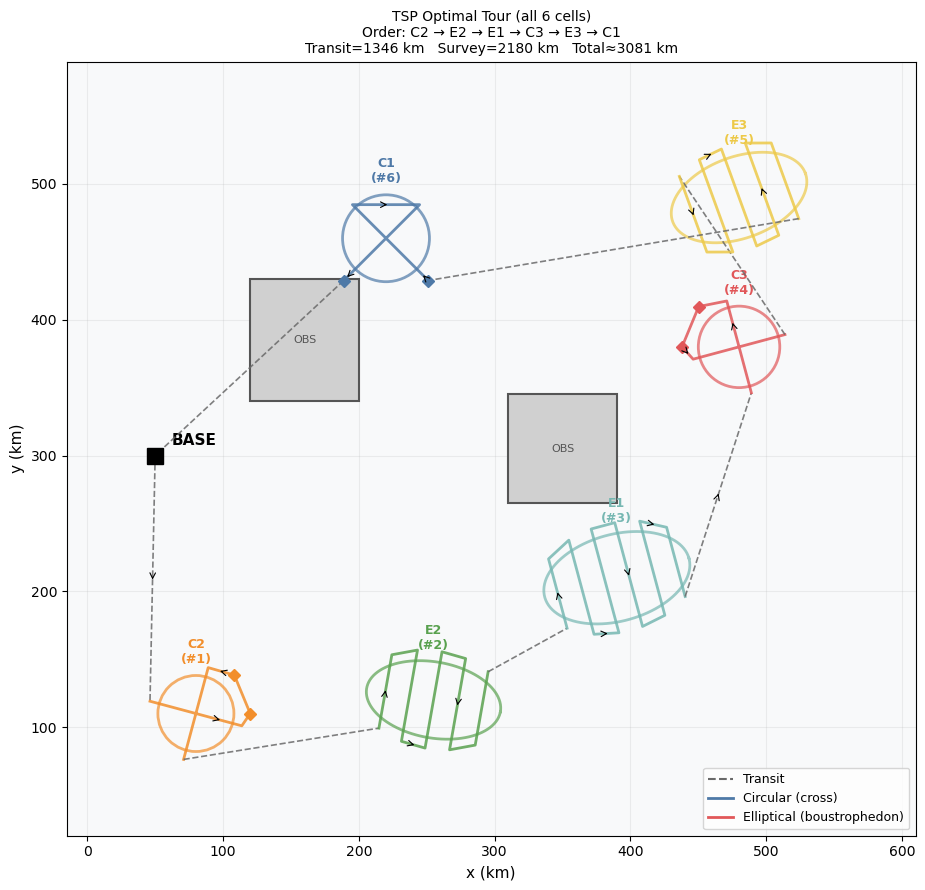

Optimal tour: C2 → E2 → E1 → C3 → E3 → C1
Figure saved → figures/tsp_comparison.png


In [7]:
# ── Route visualisation ───────────────────────────────────────────────────
# Show optimal tour with correct survey patterns (cross + boustrophedon)
opt_tour = hk_tour

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_facecolor('#f8f9fa')

for obs in OBSTACLES:
    ax.add_patch(plt.Polygon(obs, closed=True,
                             facecolor='#d0d0d0', edgecolor='#555', lw=1.5, zorder=2))
    cx=np.mean([p[0] for p in obs]); cy=np.mean([p[1] for p in obs])
    ax.text(cx,cy,'OBS',ha='center',va='center',fontsize=8,color='#555')

cell_colors={'C1':'#4e79a7','C2':'#f28e2b','C3':'#e15759',
             'E1':'#76b7b2','E2':'#59a14f','E3':'#edc948'}
for k,cell in enumerate(ALL_CELLS):
    col=cell_colors[labels[k+1]]
    if isinstance(cell,CircularSupercell):
        ax.add_patch(plt.Circle(cell.center,cell.radius,
                                fill=False,edgecolor=col,lw=2,zorder=3,alpha=0.7))
        for sp in cell.sensitivity_points:
            ax.plot(*sp,'D',color=col,ms=6,zorder=5)
    else:
        th=np.linspace(0,2*pi,200)
        R_=np.array([[cos(cell.phi),-sin(cell.phi)],[sin(cell.phi),cos(cell.phi)]])
        pts=(R_@np.vstack([cell.a*np.cos(th),cell.b*np.sin(th)])).T+cell.center
        ax.plot(pts[:,0],pts[:,1],color=col,lw=2,zorder=3,alpha=0.7)
    ax.text(cell.center[0],
            cell.center[1]+(cell.radius if isinstance(cell,CircularSupercell) else cell.b)+7,
            f'{cell.name}\n(#{opt_tour.index(k+1)+1 if k+1 in opt_tour else "–"})',
            ha='center',va='bottom',fontsize=9,fontweight='bold',color=col)

# Draw route with correct survey patterns
pos = BASE.copy(); seg_wpts = []
for k in opt_tour:
    cell=ALL_CELLS[k-1]; cfg=cell_configs[k-1][best_cfg_idx[k]]
    if isinstance(cell,CircularSupercell):
        theta=cfg['params']['theta']; L=cfg['params']['L']
        _,tr_wpts,sur_wpts,pos=route_circ_wpts(pos,cell,theta,L,OBSTACLES)
        seg_wpts.append((np.array(tr_wpts),'dimgray','transit','--'))
        seg_wpts.append((np.array(sur_wpts),cell_colors[labels[k]],labels[k],'-'))
    else:
        n_,s__=cfg['params']['n'],cfg['params']['s']
        rev,etop=cfg['params']['rev'],cfg['params']['etop']
        _,tr_wpts,sur_wpts,pos=route_ellip_wpts(pos,cell,n_,s__,DT,rev,etop,OBSTACLES)
        seg_wpts.append((np.array(tr_wpts),'dimgray','transit','--'))
        seg_wpts.append((np.array(sur_wpts),cell_colors[labels[k]],labels[k],'-'))
ret=[np.asarray(p,float) for p in multi_obs(pos,BASE,OBSTACLES)]
seg_wpts.append((np.array(ret),'dimgray','return','--'))

for wpts,col,_,ls in seg_wpts:
    if len(wpts)>=2:
        ax.plot(wpts[:,0],wpts[:,1],color=col,lw=1.2 if ls=='--' else 2,ls=ls,zorder=4,alpha=0.85)

all_wpts=np.vstack([s[0] for s in seg_wpts if len(s[0])>=2])
step=max(1,len(all_wpts)//20)
for i in range(0,len(all_wpts)-1,step):
    p1,p2=all_wpts[i],all_wpts[i+1]; dv=p2-p1; nn=np.linalg.norm(dv)
    if nn>2:
        mid=(p1+p2)/2
        ax.annotate('',xy=mid+dv/nn*3,xytext=mid-dv/nn*3,
                    arrowprops=dict(arrowstyle='->',color='black',lw=0.8),zorder=6)

ax.plot(*BASE,'ks',ms=12,zorder=7); ax.text(BASE[0]+12,BASE[1]+8,'BASE',fontsize=11,fontweight='bold')
ax.set_xlim(-15,610); ax.set_ylim(20,590); ax.set_aspect('equal'); ax.grid(True,alpha=0.2)
ax.set_xlabel('x (km)',fontsize=11); ax.set_ylabel('y (km)',fontsize=11)
tstr=' → '.join(labels[k] for k in opt_tour)
total_d=sum(path_len(s[0]) for s in seg_wpts if len(s[0])>=2)
ax.set_title(f'TSP Optimal Tour (all 6 cells)\nOrder: {tstr}\n'
             f'Transit={hk_transit:.0f} km   Survey={total_survey_cost:.0f} km   '
             f'Total≈{total_d:.0f} km', fontsize=10)
import matplotlib.lines as mlines
ax.legend(handles=[
    mlines.Line2D([],[],color='dimgray',ls='--',lw=1.5,label='Transit'),
    mlines.Line2D([],[],color='#4e79a7',ls='-',lw=2,label='Circular (cross)'),
    mlines.Line2D([],[],color='#e15759',ls='-',lw=2,label='Elliptical (boustrophedon)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('figures/tsp_comparison.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print(f'Optimal tour: {tstr}')
print(f'Figure saved → figures/tsp_comparison.png')
